<h1 id="exercise-3"><strong>Exercise 3</strong></h1>


# Answer

In [1]:
'''
The first problem with the code is that we get:
ValueError: all input arrays must have the same shape

after executing:
results = np.stack(results)

This refers to the elements of results array not being of the same shape. This arises from the empty lists that locate between rows containing data
after reading the csv file:

[[],
 ['0.013', '0.951'],
 [],
 ['0.376', '0.851'],
 [],
 ['0.441', '0.839'],
 [],
 ['0.57', '0.758'],
 [],
 ['0.635', '0.674'],
 [],
 ['0.721', '0.604'],
 [],
 ['0.837', '0.531'],
 [],
 ['0.86', '0.453'],
 [],
 ['0.962', '0.348'],
 [],
 ['0.982', '0.273'],
 [],
 ['1.0', '0.0'],
 []]

To resolve this, we can replace this part:
for row in csv_reader:
    results.append(row) 
    
with:
for row in csv_reader:
    if row != []
        results.append(row)
        
in order to append the row to the 'results' list, only if it is not an empty list.

Now, we can execute the line:
results = np.stack(results)
without getting an error.

So, the 'results' array will be:
array([['0.013', '0.951'],
       ['0.376', '0.851'],
       ['0.441', '0.839'],
       ['0.57', '0.758'],
       ['0.635', '0.674'],
       ['0.721', '0.604'],
       ['0.837', '0.531'],
       ['0.86', '0.453'],
       ['0.962', '0.348'],
       ['0.982', '0.273'],
       ['1.0', '0.0']], dtype='<U5')

The other problem is that the axis for 'recall' column (results[:, 1]) on the plot will be displayed as inverted. This occurs as the elements of the
rows of "data_file.csv" file, are read as strings, as can be seen in the above 'results' array.

To resolve this issue, we need to convert the elements which are read as strings from the file, to float. So, we can replace this part:
for row in csv_reader:
    if row != []:
        results.append(row)
results = np.stack(results)

with:
for row in csv_reader:
    if row != []:
        results.append(row)
results_float = []
for row in results:
    list1 = []
    for x in row:
        x = float(x)
        list1.append(x)
    results_float.append(list1)
results_float = np.stack(results_float)

So, the 'results' array will be:
array([[0.013, 0.951],
       [0.376, 0.851],
       [0.441, 0.839],
       [0.57 , 0.758],
       [0.635, 0.674],
       [0.721, 0.604],
       [0.837, 0.531],
       [0.86 , 0.453],
       [0.962, 0.348],
       [0.982, 0.273],
       [1.   , 0.   ]])

This way, the plot will be displayed correctly.



There is also another problem. The question asks for putting the precision column on the x axis, and the recall column on the y axis.
But the function plot_data will do it vice-versa.
We can resolve the issue by replacing this part:
plt.plot(results[:, 1], results[:, 0])
plt.ylim([-0.05, 1.05])
plt.xlim([-0.05, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')

with:
plt.plot(results_float[:, 0], results_float[:, 1])
plt.ylim([-0.05, 1.05])
plt.xlim([-0.05, 1.05])
plt.xlabel('Precision')
plt.ylabel('Recall')

'''

'\nThe first problem with the code is that we get:\nValueError: all input arrays must have the same shape\n\nafter executing:\nresults = np.stack(results)\n\nThis refers to the elements of results array not being of the same shape. This arises from the empty lists that locate between rows containing data\nafter reading the csv file:\n\n[[],\n [\'0.013\', \'0.951\'],\n [],\n [\'0.376\', \'0.851\'],\n [],\n [\'0.441\', \'0.839\'],\n [],\n [\'0.57\', \'0.758\'],\n [],\n [\'0.635\', \'0.674\'],\n [],\n [\'0.721\', \'0.604\'],\n [],\n [\'0.837\', \'0.531\'],\n [],\n [\'0.86\', \'0.453\'],\n [],\n [\'0.962\', \'0.348\'],\n [],\n [\'0.982\', \'0.273\'],\n [],\n [\'1.0\', \'0.0\'],\n []]\n\nTo resolve this, we can replace this part:\nfor row in csv_reader:\n    results.append(row) \n\nwith:\nfor row in csv_reader:\n    if row != []\n        results.append(row)\n\nin order to append the row to the \'results\' list, only if it is not an empty list.\n\nNow, we can execute the line:\nresults = np.

In [2]:
import csv
import numpy as np
from typing import Set,Tuple, List
import torch
import torch.utils
import torch.utils.data
import torch.nn as nn
import torchvision
NoneType = type(None)
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from PIL import Image
import torchvision.transforms.functional as TF
from torchvision.models import vgg11
from torchvision.models import mobilenet_v2
import torchvision.transforms as transforms
import time

<font size="4px"><p>This code plots the precision-recall curve based on data from a .csv file, where precision is on the x-axis and recall is on the y-axis. It it not so important right now what precision and recall means.</p>
<dl>
<dt>param csv_file_path</dt>
<dd><p>The CSV file containing the data to plot.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   For some reason the plot is not showing correctly, can you find out what is going wrong?</code><br />
<code>2   How could this be fixed?</code></div>
<p>This example demonstrates the issue. It first generates some data in a csv file format and the plots it using the <code>plot_data</code> method. If you manually check the coordinates and then check the plot, they do not correspond.</p>
</font>

In [3]:
# You can copy this code to your personal pipeline project or execute it here.
def plot_data(csv_file_path: str):
    """
    This code plots the precision-recall curve based on data from a .csv file,
    where precision is on the x-axis and recall is on the y-axis.
    It it not so important right now what precision and recall means.

    :param csv_file_path: The CSV file containing the data to plot.


    **This method is part of a series of debugging exercises.**
    **Each Python method of this series contains bug that needs to be found.**

    | ``1   For some reason the plot is not showing correctly, can you find out what is going wrong?``
    | ``2   How could this be fixed?``

    This example demonstrates the issue.
    It first generates some data in a csv file format and the plots it using the ``plot_data`` method.
    If you manually check the coordinates and then check the plot, they do not correspond.

    >>> f = open("data_file.csv", "w")
    >>> w = csv.writer(f)
    >>> _ = w.writerow(["precision", "recall"])
    >>> w.writerows([[0.013,0.951],
    ...              [0.376,0.851],
    ...              [0.441,0.839],
    ...              [0.570,0.758],
    ...              [0.635,0.674],
    ...              [0.721,0.604],
    ...              [0.837,0.531],
    ...              [0.860,0.453],
    ...              [0.962,0.348],
    ...              [0.982,0.273],
    ...              [1.0,0.0]])
    >>> f.close()
    >>> plot_data('data_file.csv')
    """
    # load data
    results = []
    with open(csv_file_path) as result_csv:
        csv_reader = csv.reader(result_csv, delimiter=',')
        next(csv_reader)
        for row in csv_reader:
            results.append(row)
        results = np.stack(results)

    # plot precision-recall curve
    plt.plot(results[:, 1], results[:, 0])
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.show()



In [4]:
'''
Modification by Ali:
In the cell below, I modified the 'plot_data' function according to the explanations given in the 'Answer' cell, and changed its
name to 'plot_data_modified'.
'''

"\nModification by Ali:\nIn the cell below, I modified the 'plot_data' function according to the explanations given in the 'Answer' cell, and changed its\nname to 'plot_data_modified'.\n"

In [5]:
def plot_data_modified(csv_file_path: str):
    results = []
    with open(csv_file_path) as result_csv:
        csv_reader = csv.reader(result_csv, delimiter=',')
        next(csv_reader)
        for row in csv_reader:
            if row != []:                    # Rejecting empty rows read from the csv file.
                results.append(row)
        results_float = []
        for row in results:                  # Converting the type of results' elements from str to float.
            list1 = []
            for x in row:
                x = float(x)
                list1.append(x)
            results_float.append(list1)      # Storing the new values in the 'results_float' list variable.
    results_float = np.stack(results_float)
    
    # plot precision-recall curve
    plt.plot(results_float[:, 0], results_float[:, 1])    # Displaying column 0 (Precision) on x, and column 1 (Recall) on y axis.
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.xlabel('Precision')        # Writing 'Precision' as the label of x axis.       
    plt.ylabel('Recall')           # Writing 'Recall' as the label of y axis.
    plt.show()

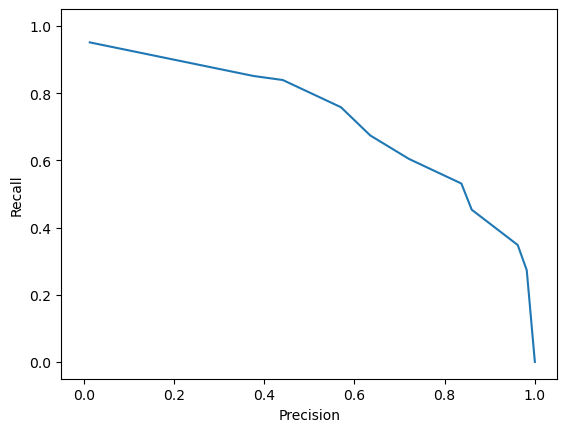

In [6]:
f = open("data_file.csv", "w")
w = csv.writer(f)
_ = w.writerow(["precision", "recall"])
w.writerows([[0.013,0.951],
             [0.376,0.851],
             [0.441,0.839],
             [0.570,0.758],
             [0.635,0.674],
             [0.721,0.604],
             [0.837,0.531],
             [0.860,0.453],
             [0.962,0.348],
             [0.982,0.273],
             [1.0,0.0]])
f.close()
plot_data_modified('data_file.csv')       # Calling 'plot_data_modified' function instead of 'plot_data' function.